# Imports and definitions

In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import copy

pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', 100)


In [2]:
import sys
from dotenv import load_dotenv
load_dotenv()

if 'google.colab' in sys.modules:
    eval_loc = os.environ['GDRIVE_EVAL_DATA_DIR']
    from google.colab import drive
    drive.mount('/content/gdrive')
elif sys.platform == 'win32':
    eval_loc = os.environ['WINDOWS_EVAL_DATA_DIR']
else:
    eval_loc = os.environ['WSL_EVAL_DATA_DIR']
print(eval_loc)

/mnt/g/My Drive/Colab Notebooks/data/grad_student_eval/


## Definitions

In [3]:
from utils import clean_award_data, is_close

# Evals

## Golden Globes

In [4]:
gg_golden_data = (pd.read_csv(eval_loc + '/picture/golden_set_gg_picture.tsv', sep = '\t')
                    .query('year >=2000 and award in ("Best Motion Picture - Drama", "Best Motion Picture - Musical or Comedy")')
                    )


#### Load Claude data

In [49]:
picture_loc = eval_loc + 'picture/'
data = {}
data['haiku4.5'] = pd.read_csv(picture_loc + 'claude_haiku_4.5_gg_picture_y6.tsv', sep = '\t')
data['sonnet4.5'] = pd.read_csv(picture_loc + 'claude_sonnet_4.5_gg_picture_y6.tsv', sep = '\t')
data['opus4.5'] = pd.read_csv(picture_loc + 'claude_opus_4.5_gg_picture_y6.tsv', sep = '\t')
data['thinking3'] = pd.read_csv(picture_loc + 'gemini_thinking_3_gg_picture_y6.tsv', sep = '\t')
data['fast3_1'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample1.tsv', sep = '\t')
data['fast3_2'] = pd.read_csv(picture_loc + 'gemini_fast_3_gg_picture_y6_sample2.tsv', sep = '\t')

for df in data.values():
    df['llm_result'] = True

In [50]:

for key, df in data.items():
    data[key] = clean_award_data(df)
gg_golden_data = clean_award_data(gg_golden_data)

### Merge and eval

In [51]:
merges = {}
for model in ['haiku4.5', 'sonnet4.5']:
    merges[model] = gg_golden_data.merge(data[model], on = ('year', 'status', 'award', 'title'), how = 'left')

for model in ['opus4.5','thinking3', 'fast3_1', 'fast3_2']:
    shift_df = data[model].copy()
    shift_df['year'] = shift_df['year'] - 1
    merges[model + '_shift'] = gg_golden_data.merge(shift_df, on = ('year', 'status', 'award', 'title'), how = 'left')

In [22]:
total = len(gg_golden_data)
gg_evals = {}
for model, merge_df in merges.items():
    if model.endswith('_shift'):
        gg_evals[model] = merge_df.query('year >= 2001')['llm_result'].sum() / total
    else:
        gg_evals[model] = merge_df['llm_result'].sum() / total

for model, accuracy in gg_evals.items():
    print(f"{model}: {accuracy:.4f}")

haiku: 0.1457
sonnet: 0.9393
opus_shift: 0.9150
thinking_shift: 0.9028
fast1_shift: 0.4615
fast2_shift: 0.9069


In [ ]:
gg_plot_df = pd.DataFrame(list(gg_evals.items()), columns=['model', 'accuracy'])

provider_colors = {'Anthropic': '#D97706', 'Gemini': '#2563EB', 'OpenAI': '#16A34A'}

def get_provider(model):
    if any(k in model for k in ['haiku', 'sonnet', 'opus', 'claude']):
        return 'Anthropic'
    if any(k in model for k in ['thinking', 'gemini', 'flash', 'fast']):
        return 'Gemini'
    if any(k in model for k in ['gpt', 'o1', 'o3', 'openai']):
        return 'OpenAI'
    return 'Other'

gg_plot_df['provider'] = gg_plot_df['model'].apply(get_provider)
gg_plot_df['color'] = gg_plot_df['provider'].map(provider_colors)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(gg_plot_df['model'], gg_plot_df['accuracy'], color=gg_plot_df['color'])
ax.set_ylim(0, 1)
ax.set_ylabel('Accuracy')
ax.set_title('Golden Globes Best Picture Prediction Accuracy')
ax.tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
present_providers = gg_plot_df['provider'].unique()
legend_elements = [Patch(facecolor=provider_colors[p], label=p)
                   for p in provider_colors if p in present_providers]
ax.legend(handles=legend_elements, title='Provider')

plt.tight_layout()
plt.show()

Missed two films because there were 7 nominees rather than 5

In [47]:
data['sonnet'].loc[data['sonnet']['title'].str.contains('commander')]

,year,status,award,title,llm_result
32,2003,nominated,best picture - drama,master and commander,True


In [ ]:
merges['sonnet'].loc[merges['sonnet']['llm_result'].isnull()]

,year,status,award,title,llm_result
23,2021,nominated,best picture - musical or comedy,"tick, tick...boom!",NaN
42,2019,winner,best picture - musical or comedy,once upon a time...in hollywood,NaN
61,2018,nominated,best picture - drama,"star is born, a",NaN
93,2014,nominated,best picture - musical or comedy,birdman or (the unexpected virtue of ignorance),NaN
150,2009,nominated,best picture - drama,precious: based on the novel push by sapphire,NaN
169,2007,nominated,best picture - drama,there will be blood,NaN
170,2007,nominated,best picture - drama,no country for old men,NaN
189,2005,nominated,best picture - musical or comedy,mrs. henderson presents,NaN
196,2004,nominated,best picture - musical or comedy,eternal sunshine of the spotless mind,NaN
197,2004,nominated,best picture - musical or comedy,the phantom of the opera,NaN


In [ ]:
### plot here
sns.barplot()

## Box office data

### Canonical data
Load TMDB movie box office data
Need to join the eval to the input list

In [ ]:
tmdb_pdf = pd.read_csv(eval_loc + 'boxoffice/tmdb_2000_2024.csv', sep = ',')
money_cols = ['worldwide', 'domestic', 'foreign']
input_pdf = pd.read_csv(eval_loc + 'boxoffice/grad_student_boxoffice_input.tsv', sep = '\t')
input_pdf = clean_award_data(input_pdf)

In [ ]:
eval_pdf = tmdb_pdf[['Release Group', '$Worldwide', '$Domestic', '$Foreign', 'Year']]
eval_pdf = clean_award_data(eval_pdf)
eval_pdf.columns = ['title', 'worldwide', 'domestic', 'foreign', 'year']
eval_pdf = eval_pdf.merge(input_pdf, on = ['title', 'year'], how = 'inner')
for col in money_cols:
  eval_pdf.loc[:,col] = (eval_pdf[col] / 1e6).round(decimals=3)
  eval_pdf.loc[:,col + '_round'] = eval_pdf[col].round(decimals=0)
eval_pdf = eval_pdf.convert_dtypes()

### Load Claude data

In [ ]:
claude = {}
gemini = {}
gemini['fast'] = pd.read_csv(eval_loc + 'boxoffice/gemini_fast_3_boxoffice_y6.tsv', sep = '\t')
gemini['thinking'] = pd.read_csv(eval_loc + 'boxoffice/gemini_thinking_research_3_boxoffice_y6.tsv', sep = '\t')
claude['haiku'] = pd.read_csv(eval_loc + 'boxoffice/claude_haiku_4.5_boxoffice_y6.tsv', sep = '\t')
claude['sonnet'] = pd.read_csv(eval_loc + 'boxoffice/claude_sonnet_4.5_boxoffice_y6.tsv', sep = '\t')
claude['opus'] = pd.read_csv(eval_loc + 'boxoffice/claude_opus_4.5_boxoffice_y6.tsv', sep = '\t')

In [ ]:
for key, df in claude.items():
  df = clean_award_data(df)
  for col in money_cols:
    df.loc[:, col] = df[col].round(decimals = 3)
    df.loc[:, col + '_round'] = df[col].round(decimals = 0).astype(pd.Int64Dtype())
  claude[key] = df.convert_dtypes()

for key, df in gemini.items():
  df = clean_award_data(df)
  for col in money_cols:
    df.loc[:, col] = df[col].round(decimals = 3)
    df.loc[:, col + '_round'] = df[col].round(decimals = 0).astype(pd.Int64Dtype())
  gemini[key] = df.convert_dtypes()

In [ ]:
haiku_merge = claude['haiku'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
sonnet_merge = claude['sonnet'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
opus_merge = claude['opus'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
fast_merge = gemini['fast'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))
thinking_merge = gemini['thinking'].merge(eval_pdf, on = ('year', 'title'), how = 'right', suffixes=( '_student', '_eval'))

### Eval

In [ ]:
stat_default = {'rounded':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0},
                            'close_1%':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0},
                            'close_5%':{'domestic':0.0, 'worldwide':0.0, 'foreign':0.0}
                             }
boxoffice_evals = { }
boxoffice_evals = {'haiku':copy.deepcopy(stat_default),
                   'sonnet':copy.deepcopy(stat_default),
                   'opus':copy.deepcopy(stat_default),
                   'fast':copy.deepcopy(stat_default),
                   'thinking':copy.deepcopy(stat_default)
                            }
for col in money_cols:
  boxoffice_evals['haiku']['rounded'][col] = (haiku_merge[col + '_round_student'] == haiku_merge[col + '_round_eval']).sum() / len(haiku_merge)
  boxoffice_evals['sonnet']['rounded'][col] = (sonnet_merge[col + '_round_student'] == sonnet_merge[col + '_round_eval']).sum() / len(sonnet_merge)
  boxoffice_evals['opus']['rounded'][col] = (opus_merge[col + '_round_student'] == opus_merge[col + '_round_eval']).sum() / len(opus_merge)
  boxoffice_evals['fast']['rounded'][col] = (fast_merge[col + '_round_student'] == fast_merge[col + '_round_eval']).sum() / len(fast_merge)
  boxoffice_evals['thinking']['rounded'][col] = (thinking_merge[col + '_round_student'] == thinking_merge[col + '_round_eval']).sum() / len(thinking_merge)

  haiku_merge['close_1%'] = is_close(haiku_merge[col + '_student'], haiku_merge[col + '_eval'], 0.01 )
  boxoffice_evals['haiku']['close_1%'][col] = haiku_merge['close_1%'].sum() / len(haiku_merge)
  sonnet_merge['close_1%'] = is_close(sonnet_merge[col + '_student'], sonnet_merge[col + '_eval'], 0.01 )
  boxoffice_evals['sonnet']['close_1%'][col] = sonnet_merge['close_1%'].sum() / len(sonnet_merge)
  opus_merge['close_1%'] = is_close(opus_merge[col + '_student'], opus_merge[col + '_eval'], 0.01 )
  boxoffice_evals['opus']['close_1%'][col] = opus_merge['close_1%'].sum() / len(opus_merge)
  fast_merge['close_1%'] = is_close(fast_merge[col + '_student'], fast_merge[col + '_eval'], 0.01 )
  boxoffice_evals['fast']['close_1%'][col] = fast_merge['close_1%'].sum() / len(fast_merge)
  thinking_merge['close_1%'] = is_close(thinking_merge[col + '_student'], thinking_merge[col + '_eval'], 0.01 )
  boxoffice_evals['thinking']['close_1%'][col] = thinking_merge['close_1%'].sum() / len(thinking_merge)

  boxoffice_evals['haiku']['close_5%'][col] = is_close(haiku_merge[col + '_student'], haiku_merge[col + '_eval'] ).sum() / len(haiku_merge)
  boxoffice_evals['sonnet']['close_5%'][col] = is_close(sonnet_merge[col + '_student'], sonnet_merge[col + '_eval']).sum() / len(sonnet_merge)
  boxoffice_evals['opus']['close_5%'][col] = is_close(opus_merge[col + '_student'], opus_merge[col + '_eval']).sum() / len(opus_merge)
  boxoffice_evals['fast']['close_5%'][col] = is_close(fast_merge[col + '_student'], fast_merge[col + '_eval']).sum() / len(fast_merge)
  boxoffice_evals['thinking']['close_5%'][col] = is_close(thinking_merge[col + '_student'], thinking_merge[col + '_eval']).sum() / len(thinking_merge)

In [ ]:
pd.concat([pd.DataFrame(boxoffice_evals['haiku']).assign(model = 'haiku'),
           pd.DataFrame(boxoffice_evals['sonnet']).assign(model = 'sonnet'),
           pd.DataFrame(boxoffice_evals['opus']).assign(model = 'opus'),
           pd.DataFrame(boxoffice_evals['fast']).assign(model = 'fast'),
           pd.DataFrame(boxoffice_evals['thinking']).assign(model = 'thinking'),
])

,rounded,close_1%,close_5%,model
domestic,0.050691,0.050691,0.069124,haiku
worldwide,0.041475,0.050691,0.059908,haiku
foreign,0.046083,0.041475,0.055300,haiku
domestic,0.806452,0.870968,0.926267,sonnet
worldwide,0.580645,0.741935,0.861751,sonnet
foreign,0.589862,0.622120,0.820276,sonnet
domestic,0.847926,0.875576,0.926267,opus
worldwide,0.474654,0.732719,0.889401,opus
foreign,0.442396,0.599078,0.857143,opus
domestic,0.027650,0.027650,0.032258,fast


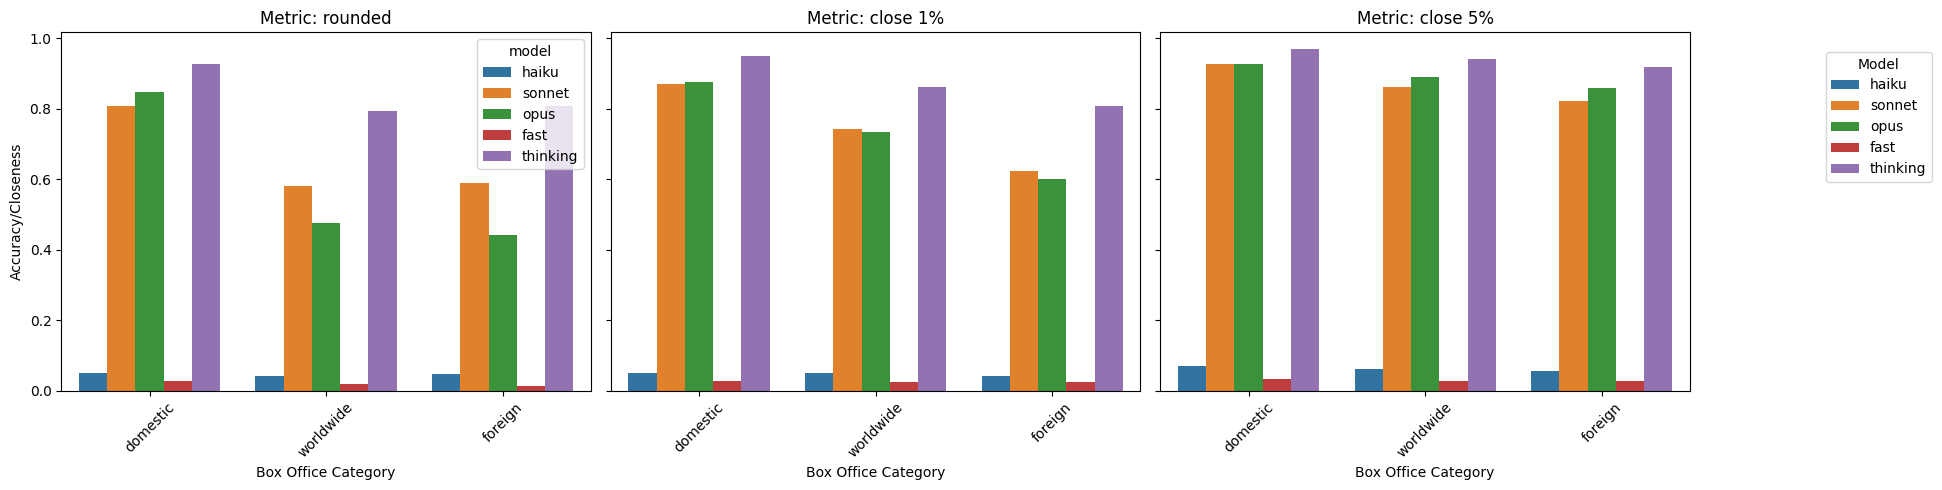

In [ ]:
data_for_plot = []
for model, metrics in boxoffice_evals.items():
    for metric_name, categories in metrics.items():
        for category, value in categories.items():
            data_for_plot.append({'model': model, 'metric': metric_name, 'category': category, 'value': value})

plot_df = pd.DataFrame(data_for_plot)

# Order metrics for consistent plotting
metric_order = ['rounded', 'close_1%', 'close_5%']
plot_df['metric'] = pd.Categorical(plot_df['metric'], categories=metric_order, ordered=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, metric in enumerate(metric_order):
    sns.barplot(data=plot_df[plot_df['metric'] == metric], x='category', y='value', hue='model', ax=axes[i])
    axes[i].set_title(f'Metric: {metric.replace("_", " ")}')
    axes[i].set_ylabel('Accuracy/Closeness' if i == 0 else '')
    axes[i].set_xlabel('Box Office Category')
    axes[i].tick_params(axis='x', rotation=45)
    if i > 0: # Remove duplicate legends
      axes[i].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Model', loc='upper right', bbox_to_anchor=(1.08, 0.9))

plt.tight_layout(rect=[0, 0, 0.95, 1]) # Adjust layout to make space for legend
plt.show()

## VES awards

### Load data

In [ ]:
ves_pdf = pd.read_csv(eval_loc + 'ves_awards/golden_set_ves_classified.tsv', sep = '\t')
ves_eval_cols = ['year', 'title', '# of nominations', 'outstanding']
ves_eval_pdf = ves_pdf.query('media_type == "film" and year >= 2019 and year <= 2024')[ves_eval_cols]
ves_eval_pdf = clean_award_data(ves_eval_pdf)

In [ ]:
claude = {}
gemini = {}
claude['opus45'] = pd.read_csv(eval_loc + 'ves_awards/claude_opus_45_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
claude['opus46'] = pd.read_csv(eval_loc + 'ves_awards/claude_opus_46_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
claude['sonnet4'] = pd.read_csv(eval_loc + 'ves_awards/claude_sonnet_thinking_4_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
claude['sonnet4']['year'] -=1
claude['sonnet45'] = pd.read_csv(eval_loc + 'ves_awards/claude_sonnet_thinking_45_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
claude['sonnet45']['year'] -=1
gemini['flash'] = pd.read_csv(eval_loc + 'ves_awards/gemini_flash_3_deep_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
gemini['flash']['year'] -=1
gemini['thinking'] = pd.read_csv(eval_loc + 'ves_awards/gemini_thinking_3_deep_ves_y6.tsv', sep = '\t').query('year >= 2019 ')
gemini['thinking']['year'] -=1

In [ ]:

for key, df in claude.items():
  print(key)
  df = clean_award_data(df)
  df['# of nominations'] = df['# of nominations'].fillna(0).astype(pd.Int64Dtype())

for key, df in gemini.items():
  df = clean_award_data(df)

opus45
opus46
sonnet4
sonnet45


In [ ]:
merges = {}
merges['opus45'] = claude['opus45'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
merges['opus46'] = claude['opus46'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
merges['sonnet45'] = claude['sonnet45'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
merges['sonnet4'] = claude['sonnet4'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
merges['flash'] = gemini['flash'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))
merges['thinking'] = gemini['thinking'].merge(ves_eval_pdf, on = ('year', 'title'), how = 'right', suffixes=('_student', '_eval'))

### Eval

In [ ]:
ves_default = {'nom_count':0.0,
               'outstanding': 0.0}
ves_evals = { }
ves_evals = {'haiku':copy.deepcopy(ves_default),
              'sonnet4':copy.deepcopy(ves_default),
              'sonnet45':copy.deepcopy(ves_default),
              'opus45':copy.deepcopy(ves_default),
              'opus46':copy.deepcopy(ves_default),
              'flash':copy.deepcopy(ves_default),
              'thinking':copy.deepcopy(ves_default)
                      }

In [ ]:
models = ['opus45', 'opus46', 'sonnet4','sonnet45', 'flash']
for model in models:
  merge_df = merges[model]
  ves_evals[model]['nom_count'] = (merge_df['# of nominations_eval'] == merge_df['# of nominations_student']).sum() / len(merge_df)
  ves_evals[model]['outstanding'] = (merge_df['outstanding_eval'] == merge_df['outstanding_student']).sum() / ves_eval_pdf['outstanding'].notnull().sum()

In [ ]:
ves_evals

{'haiku': {'nom_count': 0.0, 'outstanding': 0.0},
 'sonnet4': {'nom_count': np.float64(0.24342105263157895),
  'outstanding': np.float64(0.8245614035087719)},
 'sonnet45': {'nom_count': np.float64(0.5526315789473685),
  'outstanding': np.float64(0.49122807017543857)},
 'opus45': {'nom_count': np.float64(0.7763157894736842),
  'outstanding': np.float64(0.9473684210526315)},
 'opus46': {'nom_count': np.float64(0.0), 'outstanding': np.float64(0.0)},
 'flash': {'nom_count': np.float64(0.6993464052287581),
  'outstanding': np.float64(0.8421052631578947)},
 'thinking': {'nom_count': 0.0, 'outstanding': 0.0}}

/tmp/ipykernel_1709/4100682978.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ves_plot_df, x='model', y='nom_count', ax=axes[0], palette=colors)
/tmp/ipykernel_1709/4100682978.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ves_plot_df, x='model', y='outstanding', ax=axes[1], palette=colors)


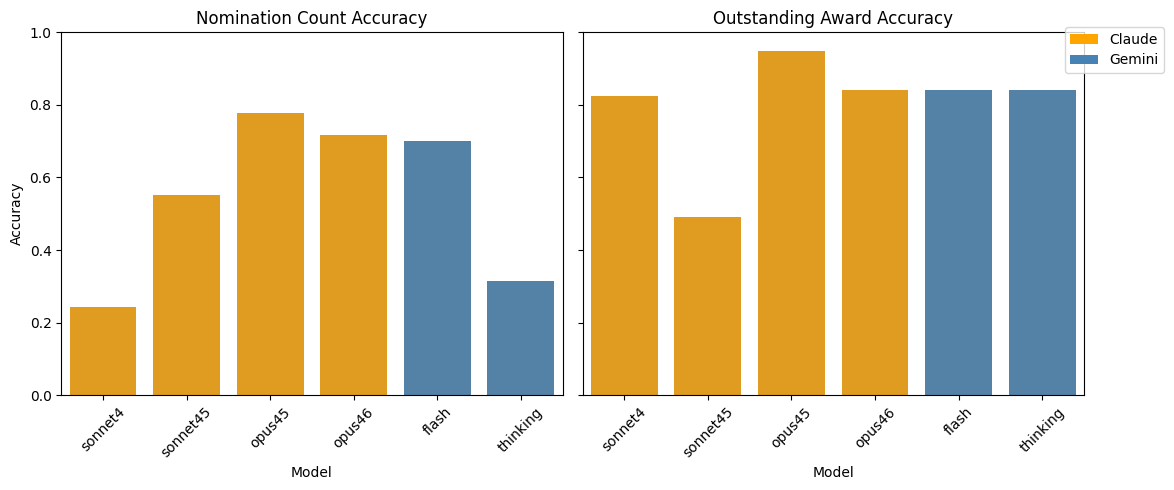

In [ ]:
ves_plot_df = pd.DataFrame(ves_evals).T.reset_index()
ves_plot_df.columns = ['model', 'nom_count', 'outstanding']
ves_plot_df = ves_plot_df.query('nom_count > 0 or outstanding > 0')

claude_models = {'sonnet4', 'sonnet45', 'opus45', 'opus46'}
colors = ['orange' if m in claude_models else 'steelblue' for m in ves_plot_df['model']]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.barplot(data=ves_plot_df, x='model', y='nom_count', ax=axes[0], palette=colors)
axes[0].set_title('Nomination Count Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_xlabel('Model')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=ves_plot_df, x='model', y='outstanding', ax=axes[1], palette=colors)
axes[1].set_title('Outstanding Award Accuracy')
axes[1].set_ylabel('')
axes[1].set_xlabel('Model')
axes[1].tick_params(axis='x', rotation=45)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='orange', label='Claude'), Patch(facecolor='steelblue', label='Gemini')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.98, 0.95))

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

## Earnings Transcripts

### Load data and merge

In [ ]:
earnings_pdf = pd.read_csv(eval_loc + 'earnings_transcripts/golden_set_earnings.tsv', sep = '\t')
earnings_eval_pdf = earnings_pdf.query('quarter >="2019Q1"')
earnings_eval_pdf = clean_award_data(earnings_eval_pdf)
earnings_eval_pdf.sample(3)

,quarter,ai_all,ai_meta,metaverse_all,metaverse_meta,reels_all,reels_meta
17,2023Q1,53,44,17,17,39,36
18,2023Q2,52,49,27,25,16,15
28,2025Q4,36,34,5,5,5,5


In [ ]:
data = {}
data['haiku46'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_haiku_46_earnings_y6.tsv', sep = '\t')
data['haiku46_research'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_haiku_research_46_earnings_y6.tsv', sep = '\t')
data['sonnet46_research'] = pd.read_csv(eval_loc + 'earnings_transcripts/claude_sonnet_research_46_earnings_y6.tsv', sep = '\t')
data['fast3'] = pd.read_csv(eval_loc + 'earnings_transcripts/gemini_fast_3_earnings_y6.tsv', sep = '\t')
data['fast3_deep'] = pd.read_csv(eval_loc + 'earnings_transcripts/gemini_fast_deep_3_earnings.tsv', sep = '\t')

In [ ]:
merges = {}
models = ['haiku46', 'haiku46_research', 'sonnet46_research', 'fast3', 'fast3_deep']

for model in models:
    print(model)
    merges[model] = data[model].merge(earnings_eval_pdf, on = 'quarter', how='right', suffixes = ('_student', '_eval'))

haiku46
haiku46_research
sonnet46_research
fast3
fast3_deep


### Evals

In [ ]:
stat_default = {'exact': {'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                'close_10%':{'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                'close_20%':{'ai_all':0.0, 'ai_meta':0.0, 'metaverse_all':0.0, 'metaverse_meta':0.0, 'reels_all':0.0, 'reels_meta':0.0},
                    }
earnings_evals = { }
earnings_evals = {'haiku46':copy.deepcopy(stat_default),
                  'haiku46_research':copy.deepcopy(stat_default),
                   'sonnet46':copy.deepcopy(stat_default),
                   'sonnet46_research':copy.deepcopy(stat_default),
                   'opus':copy.deepcopy(stat_default),
                   'fast3':copy.deepcopy(stat_default),
                   'fast3_deep':copy.deepcopy(stat_default),
                   'thinking3':copy.deepcopy(stat_default)
                            }
earnings_cols = ['ai_all',	'ai_meta',	'metaverse_all'	,'metaverse_meta',	'reels_all',	'reels_meta']
for col in earnings_cols:
    for model in models:
        earnings_evals[model]['exact'][col] =( merges[model][col + '_student'] == merges[model][col + '_eval']).sum() / len(merges[model])
        earnings_evals[model]['close_10%'][col] = is_close( merges[model][col + '_student'],  merges[model][col + '_eval'], 0.1).sum() / len(merges[model])
        
        earnings_evals[model]['close_20%'][col] = is_close( merges[model][col + '_student'],  merges[model][col + '_eval'], 0.2).sum() / len(merges[model])

In [ ]:
earnings_eval_pdf = pd.concat([pd.DataFrame(earnings_evals[model]).assign(model = model) for model in models]).reset_index()
earnings_eval_pdf.columns = ['token_type', 'exact','close_10%', 'close_20%', 'model']
earnings_eval_pdf.sample(3)

,token_type,exact,close_10%,close_20%,model
21,metaverse_meta,0.000000,0.000000,0.000000,fast3
8,metaverse_all,0.285714,0.214286,0.464286,haiku46_research
14,metaverse_all,0.357143,0.142857,0.392857,sonnet46_research


In [ ]:
earnings_eval_plot_pdf = pd.melt(earnings_eval_pdf, id_vars = ['model', 'token_type'], value_vars = ['exact', 'close_10%', 'close_20%'], var_name = 'metric', value_name = 'value')
earnings_eval_plot_pdf.sample(2)

,model,token_type,metric,value
8,haiku46_research,metaverse_all,exact,0.285714
32,haiku46,metaverse_all,close_10%,0.071429


<Axes: xlabel='metric', ylabel='value'>

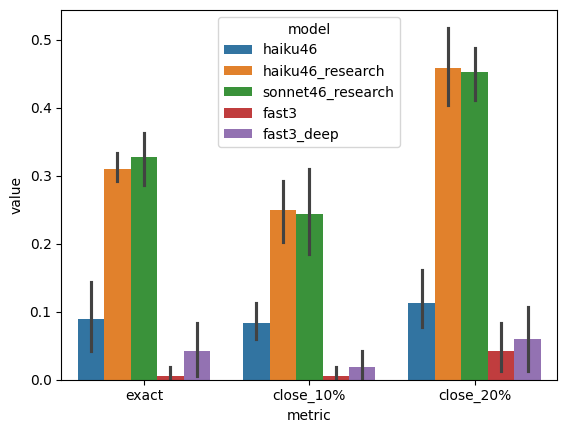

In [ ]:
sns.barplot(data=earnings_eval_plot_pdf, hue='model', y='value', x='metric'
           )